## Lending Club Case Study

<h3 style="color:Blue;">Introduction</h3>

Solving this assignment will give you an idea about how real business problems are solved using EDA. In this case study, apart from applying the techniques you have learnt in EDA, you will also develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimise the risk of losing money while lending to customers.

### Importing Library

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Reading the data from loan.csv file 

In [11]:
ldf=pd.read_csv("loan.csv")

/var/folders/m1/s7tlw0zs27sfn4nlx59tf6lh0000gn/T/ipykernel_27421/2259820094.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  ldf=pd.read_csv("loan.csv")


### Functions to understand the structure and properties of the DataFrame columns

In [12]:
def understanding_columns(ldf):
    str_cols=ldf.select_dtypes(include=['object', 'string']).columns
    first_values = ldf[str_cols].iloc[0]
    result = pd.DataFrame({'column': str_cols, 'first_value': first_values.values})
    return result

understanding_columns(ldf)

,column,first_value
0,term,36 months
1,int_rate,10.65%
2,grade,B
3,sub_grade,B2
4,emp_title,NaN
5,emp_length,10+ years
6,home_ownership,RENT
7,verification_status,Verified
8,issue_d,Dec-11
9,loan_status,Fully Paid


#### As we can see there are many columns with Object datatype and there may come a need to convert them to float type if any groupby or aggregation needs to be done ahead

In [13]:
def convert_to_float(colname):
    return colname.apply(lambda x:0.0 if x == 0 else float(x))

#### Creating a function that will clean the given DataFrame by handling missing values and inconsistent data

In [14]:
def data_cleaning(ldf):
    cols_to_drop = ldf.columns[ldf.isnull().sum() == 39717].tolist()
    ldf=ldf.drop(columns=cols_to_drop)
    #further checking if any of the remaining columns have null values >50% of their rows as they will not offer much in analysis 
    cols_to_drop2= ldf.columns[(ldf.isnull().mean() *100)>50].tolist()
    ldf=ldf.drop(columns=cols_to_drop2)

    #fitering all string and object columns to perform basic cleaning like removing any whitespace, replacing wild characters, filling null with a specific string
    str_cols = ldf.select_dtypes(include=['object', 'string']).columns
    ldf[str_cols] = (
        ldf[str_cols]
        .apply(lambda col: col.str.strip())
        .apply(lambda col: col.str.lower())
        .replace(r'[%+]', '', regex=True)
        .fillna('unknown')
    )
    #clean numeric columns, filling them with median
    num_cols = ldf.select_dtypes(include=['number']).columns
    for col in num_cols:
        median_val = ldf[col].median()
        ldf[col] = ldf[col].fillna(median_val)

    ldf['loan_amnt'] =convert_to_float(ldf['loan_amnt'])
    ldf['int_rate']=convert_to_float(ldf['int_rate'])
    
    ldf['term']=ldf['term'].str.replace("months","")
    ldf['term']=convert_to_float(ldf['term'])
    
    #extract years from date columns
    ldf['issue_month']=pd.to_datetime(ldf['issue_d'],format='%b-%y',errors='coerce').dt.month

    #finally print the total null values in the dataframe, if its less than 10% then we are good to do EDA
    print(ldf.isnull().mean().sort_values(ascending=False) *100)

    return ldf

In [15]:
cleaned_ldf_data=data_cleaning(ldf)

id                            0.0
recoveries                    0.0
revol_bal                     0.0
revol_util                    0.0
total_acc                     0.0
initial_list_status           0.0
out_prncp                     0.0
out_prncp_inv                 0.0
total_pymnt                   0.0
total_pymnt_inv               0.0
total_rec_prncp               0.0
total_rec_int                 0.0
total_rec_late_fee            0.0
collection_recovery_fee       0.0
open_acc                      0.0
last_pymnt_d                  0.0
last_pymnt_amnt               0.0
last_credit_pull_d            0.0
collections_12_mths_ex_med    0.0
policy_code                   0.0
application_type              0.0
acc_now_delinq                0.0
chargeoff_within_12_mths      0.0
delinq_amnt                   0.0
pub_rec_bankruptcies          0.0
tax_liens                     0.0
pub_rec                       0.0
inq_last_6mths                0.0
member_id                     0.0
annual_inc    

<h3 style="color:Blue;">Univariate Analysis</h3>

#### 1. Starting with Numeric variables 
 1. Most important factor to identify risks is by analysing loan status. 
 2. Below picture shows 14% are of loans are charged off ie. defaulted

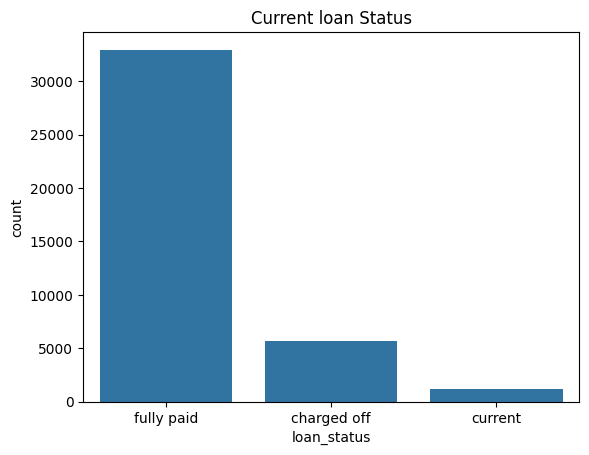

loan_status
fully paid     82.961956
charged off    14.167737
current         2.870307
Name: proportion, dtype: float64


In [16]:
sns.countplot(x='loan_status',data=cleaned_ldf_data)
plt.title("Current loan Status")
plt.show()

counts= cleaned_ldf_data['loan_status'].value_counts(normalize=True)*100
print(counts)

#### 2. Loan amount is also a very important variable for a loan company to consider its overall risk
 1. In our case study, we can clearly see most loans are taken between 1000-35000 and the concentration is specifically in small loans that is <20000 


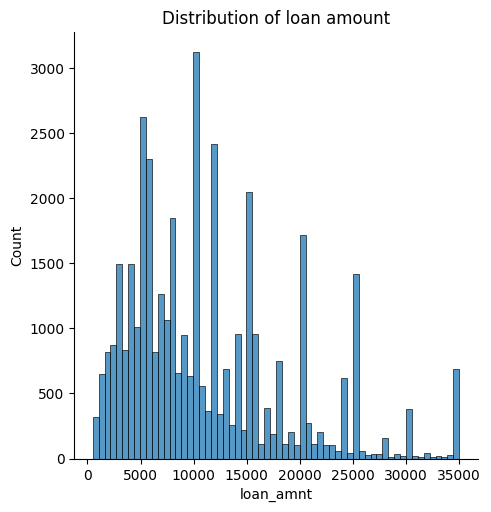

In [17]:
sns.displot(cleaned_ldf_data['loan_amnt'])
plt.title('Distribution of loan amount')
plt.show()

#### 3. Looking at the Interest rate of this company will tell its risk zones
1. The below plot shows us that 50% of loans fall between 10-15interest rate,hence its the most typical interest rate given

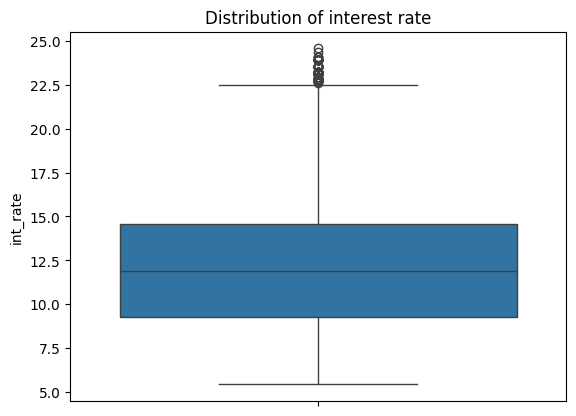

In [18]:

sns.boxplot(y=cleaned_ldf_data['int_rate'])
plt.title('Distribution of interest rate')
plt.show()

#### 4. DTI =0 means no debt, 10= debt is 10% of the income, as the plot indicates, dti goes down at the end meaning very less borrowers are risky, which is common as lenders dont approve loans for people with high dti

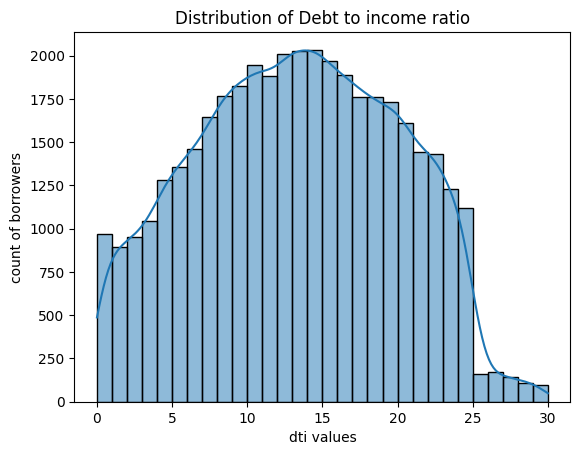

In [19]:

sns.histplot(cleaned_ldf_data['dti'],kde=True,bins=30)
plt.title('Distribution of Debt to income ratio')
plt.xlabel('dti values')
plt.ylabel('count of borrowers')
plt.show()

#### 5. Below categorical plots explain how loans are structured within this loan company by looking at the column 'grade'

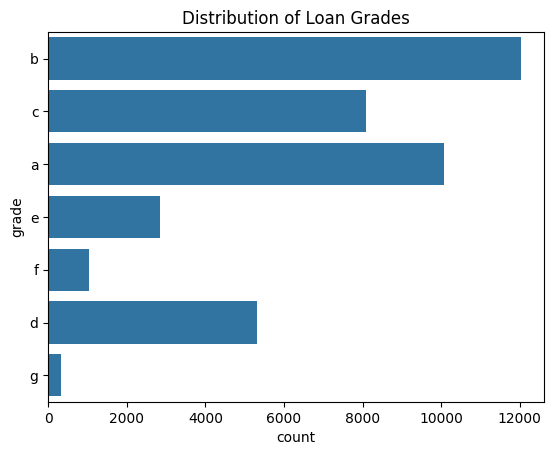

In [20]:

sns.countplot(cleaned_ldf_data['grade'])
plt.title("Distribution of Loan Grades")
plt.show()

#### 6. By plotting a graph on column 'purpose' from the dataset provides an insight on the reason for loan

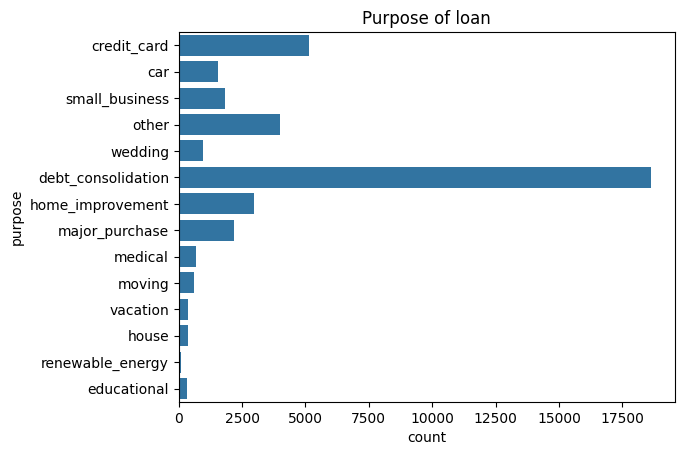

In [21]:
sns.countplot(y='purpose',data=cleaned_ldf_data, order=cleaned_ldf_data['purpose'])
plt.title("Purpose of loan")
plt.show()

#### 7. Term

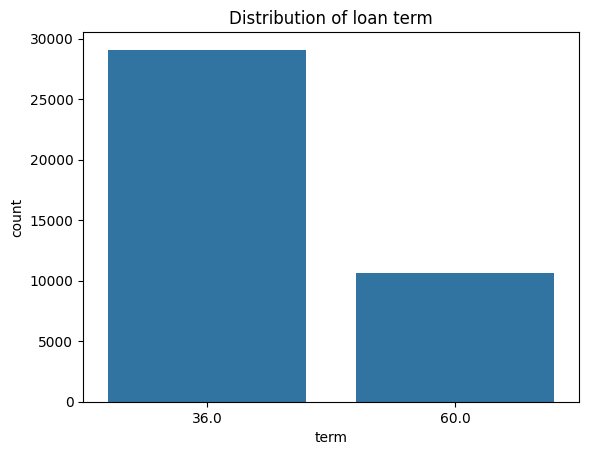

In [22]:
sns.countplot(x="term",data=cleaned_ldf_data)
plt.title("Distribution of loan term")
plt.show()

<h3 style="color:Blue;">Bivariate Analysis</h3>

#### 1. Lets use two variables to understand their relation by plotting them as a countplot
### Grade vs Loan status

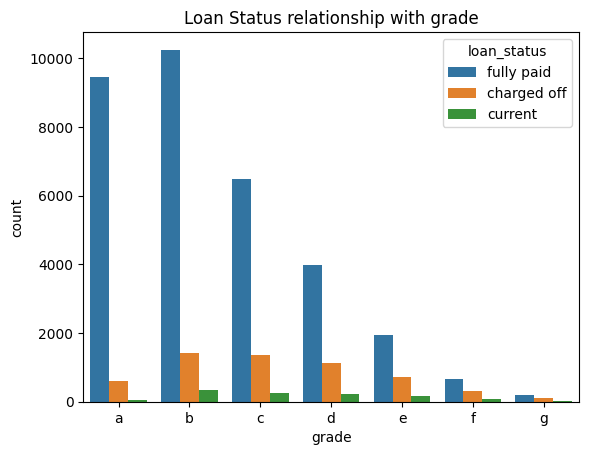

In [23]:
sns.countplot(data=cleaned_ldf_data, x="grade",hue="loan_status", order=sorted(cleaned_ldf_data['grade'].unique()))
plt.title("Loan Status relationship with grade")
plt.show()

#### 2. Lets look at Loan status versus loan amount. To see if the status varies by the amount of money taken on loan by the candidates

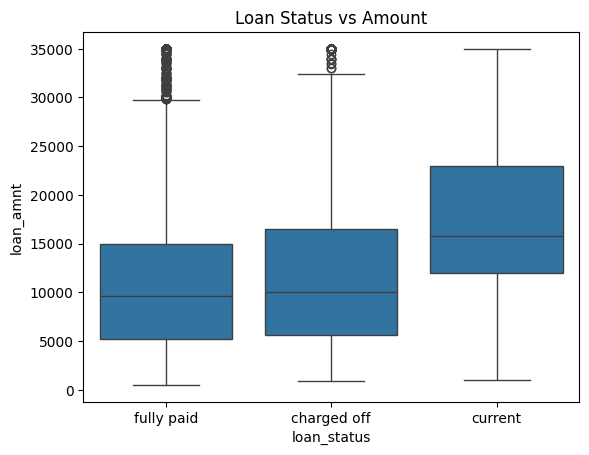

In [24]:
sns.boxplot(x="loan_status", y="loan_amnt",data=cleaned_ldf_data)
plt.title("Loan Status vs Amount")
plt.show()


#### 3. As interest rate is a driving factor for repayment of loan, lets plot a box plot on loan_status and interest rate 

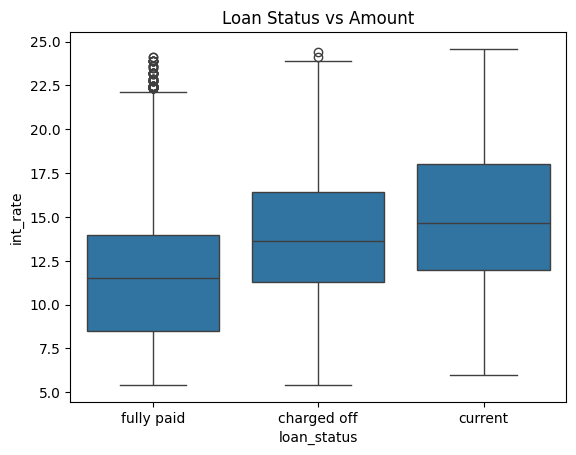

In [29]:

sns.boxplot(x="loan_status", y="int_rate",data=cleaned_ldf_data)
plt.title("Loan Status vs Amount")
plt.show()

<h3 style="color:Blue;">Multivariate Analysis</h3>

#### To analyze the trend on loan default, we must first convert loan status in binary

In [26]:
cleaned_ldf_data['loan_status'].unique()
cleaned_ldf_data['default_flag']=cleaned_ldf_data['loan_status'].isin(['charged off','default']).astype(int)  

#### This plot proves grade g defaults the highest and are most risky

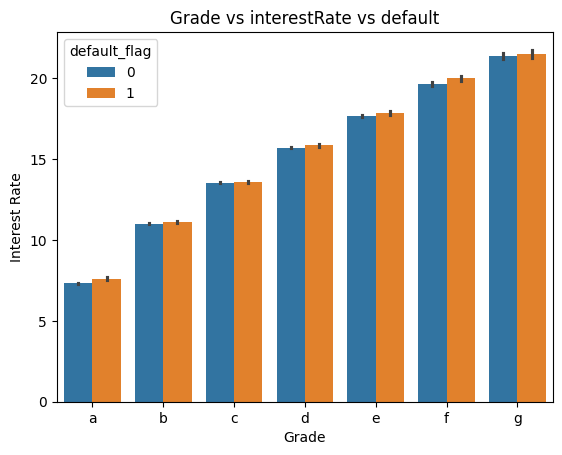

In [27]:
default_rate=cleaned_ldf_data.groupby('grade')['default_flag'].mean().reset_index()
sns.barplot(x='grade', y='int_rate',hue="default_flag", data=cleaned_ldf_data,order=sorted(cleaned_ldf_data['grade']))
plt.title("Grade vs interestRate vs default")
plt.xlabel('Grade')
plt.ylabel('Interest Rate')
plt.show()

#### Correlation 

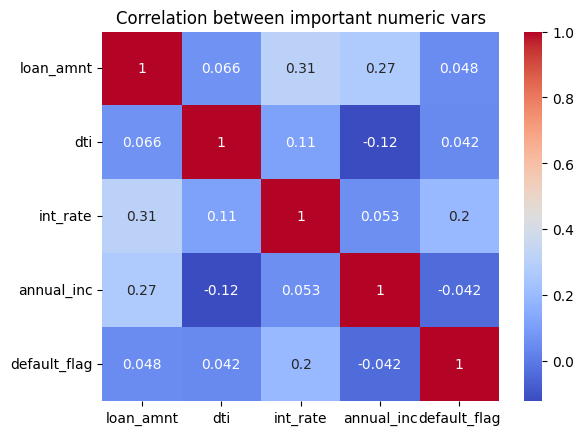

In [30]:

corr=cleaned_ldf_data[['loan_amnt','dti','int_rate','annual_inc','default_flag']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation between important numeric vars")
plt.show()